# E9 — Test-Time Compute, Measured

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Solve a real routing problem **exactly** by enumeration, so that every later result is graded against a known optimum rather than against another guess
- Turn "try again" into a measured quantity: plot **accuracy against compute budget** for three search policies on one shared axis
- Discover from your own numbers that the budget curve is **not** the textbook `1 − (1 − p)ⁿ` law, and work out why
- Spend the *same* compute two different ways — more attempts vs more work per attempt — and say which wins, at which budget
- Watch best-of-*n* selection **stop working** when the thing choosing the winner is imperfect

## 🔗 Where this fits

**Builds on:** Unit 1, lesson 02 `02_search_algorithms.ipynb` — BFS, DFS, Dijkstra and A\* on a graph, and the complexity analysis at the end of it. That lesson's promise is that a complete search *guarantees* the optimal path. This notebook starts by cashing that guarantee in (we enumerate every tour to get ground truth), then asks the question the complexity table implies but does not answer: **what do you do when the complete search is too big to run, and how much accuracy does each extra second of guessing actually buy?**

**Used later in:** Course 02 Unit 4 `01_optimization_techniques.ipynb`, where searching a space for the best option returns as numerical optimization with the same restart-and-keep-the-best structure; and Course 09 (AIAT 123) Unit 4 `03_adaptive_exploration_ucb.ipynb`, where UCB turns "how much of my budget should this decision get?" from a fixed number into a rule.

## 🌍 Why this matters: the field bought its 2025 reasoning gains at inference time

For a decade, "make the model better" meant **train** something bigger. Since 2024 it also means **spend more
compute per question at answer time** — and this notebook is that idea with the language model removed, so you
can measure it in seconds on a laptop.

**Where it starts.** Cobbe, Kosaraju, Bavarian, Chen and colleagues (OpenAI, 2021,
[arXiv:2110.14168](https://arxiv.org/abs/2110.14168)) proposed *"training verifiers to judge the correctness of
model completions"*, and then: *"At test time, we generate many candidate solutions and select the one ranked
highest by the verifier."* That is **best-of-n**, and it is exactly the loop below: propose many, keep the one
the checker likes.

**Where it became a budget decision.** Snell, Lee, Xu and Kumar (2024,
[arXiv:2408.03314](https://arxiv.org/abs/2408.03314)) titled their paper *Scaling LLM Test-Time Compute
Optimally can be More Effective than Scaling Model Parameters*, and reported that on problems where a smaller
model already has *"somewhat non-trivial success rates, test-time compute can be used to outperform a 14x larger
model."* Their compute-optimal allocation improved *"the efficiency of test-time compute scaling by more than 4x
compared to a best-of-N baseline"* — the allocation matters as much as the amount.

**Where it became a product.** DeepSeek-R1 (DeepSeek-AI, January 2025,
[arXiv:2501.12948](https://arxiv.org/abs/2501.12948)) made long inference-time reasoning an openly documented
capability, and Muennighoff, Yang, Shi and colleagues (2025, [arXiv:2501.19393](https://arxiv.org/abs/2501.19393))
showed the crudest possible version of the knob already works: **budget forcing**, *"forcefully terminating the
model's thinking process or lengthening it"*, with their s1-32B *"exceeding o1-preview on competition math
questions by up to 27% (MATH and AIME24)"*.

**Why a routing problem is the right place to learn this.** In all four papers the y-axis is accuracy and the
x-axis is compute — but you cannot check their answers, because verifying a maths proof is itself hard. In our
problem the optimum is **computable by brute force**, so "did it get it right?" is a fact, not an opinion. Every
curve below is graded against an answer we own.

## 📥 Inputs & 📤 Outputs

**Inputs:** the repository's real **Montgomery County 911 dispatch log** — actual emergency calls with latitude
and longitude, loaded in one line with `load("montgomery_911_calls", prefer="sample")`. No file path, no
download, no model: the loader finds the data from any folder, and on Google Colab where there is no repository
at all. We keep the recurring call addresses in one township (Norristown, Pennsylvania) and use them as the
stops a single vehicle must visit.

**Which copy of the log, and why we pick the sample on purpose.** The complete log is **663,522 calls, 123 MB**
— far too large to ship inside a repository. What runs here is therefore the **25,000-row sample that ships with
the repo**: one call in every 27, evenly spread, covering the same 2015-12-10 to 2020-07-29 window. We ask for
it *explicitly*, even on a machine that has downloaded the full file, because this notebook promises that your
numbers will match the printed ones — and that promise only holds if every reader loads the same rows. **Every
number in this notebook is a number about those 25,000 calls**, and the first code cell prints that fact out
loud each time it runs.

**Outputs:** the exact optimal tour length for 30 real 10-stop routes, found by enumerating all 362,880 tours;
a per-attempt trace of one local search; an accuracy-versus-compute table and chart for three policies on one
axis; the same curve split by instance difficulty; and a best-of-*n* curve under an imperfect verifier.

**Randomness note.** Everything random in this notebook is random *on purpose* — which stops make up an
instance, where each restart begins, and the simulated measurement error of the verifier in Part 6. The
coordinates themselves are real call locations, and every seed is fixed, so your numbers will match these.

## Part 1: A Real Routing Task With a Knowable Answer

One vehicle leaves a base, visits nine more locations, and returns. Which order is shortest? This is the
travelling salesman problem, and for **n** stops there are **(n−1)!/2** distinct tours.

Lesson 02 built BFS, DFS, Dijkstra and A\* and finished with a complexity table. This is that table with real
consequences attached: complete enumeration is *available* to us at 10 stops and *gone* by 15. We will use it
while we still can — not to solve the problem, but to know the answer we are grading against.

In [1]:
# WHAT: load real 911 call locations, keep the recurring addresses of one township, and convert
#       latitude/longitude into kilometres so that straight-line distances mean something.
# WHY : an instance made of real coordinates has real structure - clusters along main roads, a few
#       outliers - and that structure is what makes some routes easy and others hard later on.
import itertools
import math
import time

import numpy as np
import pandas as pd

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/montgomery_911_calls.csv' only resolves
#       when the kernel's working directory happens to be this notebook's folder, and that file
#       is 123 MB - too big to ship. This does not care where you are, and needs no download.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------

# prefer="sample" is deliberate. This notebook promises that your numbers will match the ones
# printed here, and that promise only holds if every machine reads the SAME rows - so we always
# read the 25,000-row sample that ships in the repository, even on a machine that happens to
# have downloaded the 663,522-row original. The loader says so out loud on the line below.
calls = load("montgomery_911_calls", prefer="sample", usecols=["lat", "lng", "twp", "addr"])
town = calls[calls["twp"] == "NORRISTOWN"].dropna(subset=["lat", "lng", "addr"])

# One row per address, with its mean coordinate and how often it appears in the log.
sites = (town.groupby("addr")
              .agg(lat=("lat", "mean"), lng=("lng", "mean"), calls=("addr", "size")))
sites = sites[sites["calls"] >= 5].sort_values("calls", ascending=False)

# Equirectangular projection: at this latitude one degree of longitude is shorter than one of latitude.
lat0, lng0 = float(sites["lat"].mean()), float(sites["lng"].mean())
XY = np.c_[(sites["lng"].to_numpy() - lng0) * 111.32 * np.cos(np.radians(lat0)),
           (sites["lat"].to_numpy() - lat0) * 111.32]

if len(sites) < 50:
    raise RuntimeError(f"Expected 50+ recurring addresses, found {len(sites)}.")

print(f"\n{len(calls):,} dispatch records read -> {len(town):,} in NORRISTOWN "
      f"-> {len(sites)} addresses with 5+ calls in that sample")
print(f"Area covered: {np.ptp(XY[:, 0]):.1f} km east-west by {np.ptp(XY[:, 1]):.1f} km north-south\n")
print("The five busiest addresses (address 0 is the base every route starts and ends at):\n")
print(sites.head(5).round(4).to_string())


montgomery_911_calls: bundled 25,000-row sample of the 663,522-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: 1 row in every 27, evenly spread, so the sample covers the same 2015-12-10 to 2020-07-29 window with all 100 call types and 68 townships.

25,000 dispatch records read -> 1,515 in NORRISTOWN -> 85 addresses with 5+ calls in that sample
Area covered: 3.9 km east-west by 2.9 km north-south

The five busiest addresses (address 0 is the base every route starts and ends at):

                             lat      lng  calls
addr                                            
LAFAYETTE ST & SWEDE ST  40.1138 -75.3451     33
MAIN ST & BARBADOES ST   40.1157 -75.3476     25
WALNUT ST & E MAIN ST    40.1118 -75.3369     23
PINE ST & W ROBERTS ST   40.1294 -75.3322     22
LOCUST ST & DOGWOOD DR   40.1332 -75.3438     21


## Part 2: The Optimum, by Complete Enumeration

We fix the base as the first and last stop and enumerate every ordering of the other nine: **9! = 362,880**
tours per instance. That is a complete search — the thing lesson 02 promised would always find the optimum —
and here it costs a fraction of a second.

Then look at the third column of the table it prints. Complete enumeration is not a method you can grow into.
It is a window that closes.

In [2]:
# WHAT: build 30 routing instances from real addresses and solve every one of them EXACTLY.
# WHY : the whole notebook depends on knowing the true optimum. We compute it once, by enumeration,
#       and every later policy is graded against it - so "accuracy" below means "found the provably
#       shortest tour", not "found a tour that looked good".
N_STOPS = 10          # base + 9 stops
N_INSTANCES = 30      # 30 different real routes
SEED = 20260829

rng = np.random.default_rng(SEED)

# Every ordering of stops 1..9, with the base (0) pinned at both ends: shape (362880, 11).
orderings = np.array(list(itertools.permutations(range(1, N_STOPS))), dtype=np.int16)
ALL_TOURS = np.hstack([np.zeros((len(orderings), 1), np.int16),
                       orderings,
                       np.zeros((len(orderings), 1), np.int16)])

t0 = time.time()
instances = []
for k in range(N_INSTANCES):
    # stop 0 is the busiest address (the base); the other nine are sampled real addresses
    chosen = np.concatenate([[0], rng.choice(np.arange(1, len(sites)), size=N_STOPS - 1, replace=False)])
    points = XY[chosen]
    dist = np.sqrt(((points[:, None, :] - points[None, :, :]) ** 2).sum(-1))   # km between every pair
    tour_costs = dist[ALL_TOURS[:, :-1], ALL_TOURS[:, 1:]].sum(1)              # cost of all 362,880 tours
    instances.append({"dist": dist,
                      "dist_list": dist.tolist(),      # plain lists are much faster in Python loops
                      "optimum": float(tour_costs.min()),
                      "mean_tour": float(tour_costs.mean()),
                      "worst": float(tour_costs.max())})
enumeration_seconds = time.time() - t0

optima = np.array([inst["optimum"] for inst in instances])
print(f"{N_INSTANCES} instances x {len(ALL_TOURS):,} tours enumerated in {enumeration_seconds:.2f} s")
print(f"Optimal tour length: min {optima.min():.2f} km, median {np.median(optima):.2f} km, "
      f"max {optima.max():.2f} km")
print(f"Average tour length across all orderings: {np.mean([i['mean_tour'] for i in instances]):.2f} km "
      f"- so a tour picked at random is about "
      f"{np.mean([i['mean_tour'] for i in instances]) / optima.mean():.1f}x the optimum\n")

print(f"Each tour has the same length driven backwards, so those {len(ALL_TOURS):,} orderings are")
print(f"{len(ALL_TOURS) // 2:,} distinct tours. Now watch that number as stops are added:\n")
print(f"{'stops':>6} {'distinct tours':>22} {'time at 10 million tours/second':>34}")
for n in (10, 12, 15, 20, 25):
    tours = math.factorial(n - 1) / 2          # (n-1)!/2 distinct tours through n stops
    seconds = tours / 1e7
    if seconds < 60:
        pretty = f"{seconds:.2f} seconds"
    elif seconds < 86400:
        pretty = f"{seconds / 3600:.1f} hours"
    elif seconds < 3.15e7:
        pretty = f"{seconds / 86400:.0f} days"
    else:
        pretty = f"{seconds / 3.15e7:,.0f} years"
    print(f"{n:>6} {tours:>22,.0f} {pretty:>34}")

30 instances x 362,880 tours enumerated in 0.65 s
Optimal tour length: min 3.33 km, median 7.08 km, max 9.12 km
Average tour length across all orderings: 11.43 km - so a tour picked at random is about 1.7x the optimum

Each tour has the same length driven backwards, so those 362,880 orderings are
181,440 distinct tours. Now watch that number as stops are added:

 stops         distinct tours    time at 10 million tours/second
    10                181,440                       0.02 seconds
    12             19,958,400                       2.00 seconds
    15         43,589,145,600                          1.2 hours
    20 60,822,550,204,416,000                          193 years
    25 310,224,200,866,619,704,999,936                  984,838,733 years


## Part 3: One Attempt — a Random Start Plus 2-opt

When enumeration is gone, you guess and improve. One **attempt** here is:

1. start from a random ordering of the nine stops;
2. repeatedly apply **2-opt** — pick two edges, reverse the segment between them, keep the change if the tour
   got shorter — until no single reversal helps any more.

That end state is a **local optimum**: no *one* move improves it, which is not at all the same as being the
shortest tour. Different random starts fall into different local optima, and that is the only reason restarting
is worth anything.

**The compute unit.** We count every read of the distance table — one *distance lookup*. Scoring a whole tour
costs 10 lookups; testing one 2-opt move costs 4 (two edges removed, two added). Counting lookups instead of
seconds means the comparison in Part 4 does not depend on how fast your laptop is, and it is the same trick the
test-time-compute literature uses when it plots accuracy against FLOPs instead of wall-clock time.

In [3]:
# WHAT: the three policies. `random_tour` guesses. `local_search` guesses then improves with 2-opt,
#       either for one improvement pass (shallow) or all the way to a local optimum (deep).
# WHY : these are our stand-ins for "one cheap attempt" and "one expensive attempt". Everything in
#       Part 4 comes from running them under an identical compute budget, so the accounting of
#       `lookups` below is the load-bearing part of the code, not a decoration.
def tour_length(tour, dist_list):
    """Total km of a tour given as a list of stop indices. Costs len(tour) - 1 distance lookups."""
    return sum(dist_list[tour[i]][tour[i + 1]] for i in range(len(tour) - 1))


def local_search(tour, dist_list, max_passes):
    """2-opt improvement. Returns (tour length, distance lookups spent).

    A 2-opt move cuts edges (a,b) and (c,d) and reconnects them as (a,c) and (b,d), which reverses
    the segment between b and c. We evaluate it as a DELTA - four lookups - instead of rescoring the
    whole tour, which is why one attempt is affordable at all.
    """
    lookups = len(tour) - 1
    cost = tour_length(tour, dist_list)
    improved, passes = True, 0
    while improved and passes < max_passes:
        improved, passes = False, passes + 1
        for i in range(1, len(tour) - 2):
            for j in range(i + 1, len(tour) - 1):
                a, b, c, d = tour[i - 1], tour[i], tour[j], tour[j + 1]
                lookups += 4
                delta = dist_list[a][c] + dist_list[b][d] - dist_list[a][b] - dist_list[c][d]
                if delta < -1e-12:                       # strictly shorter: take it
                    tour[i:j + 1] = tour[i:j + 1][::-1]
                    cost += delta
                    improved = True
    return cost, lookups


# --- three attempts on the same instance, so you can see the lottery ----------------------------
DEMO = 12                      # one of the harder routes - Part 5 measures what makes it hard
demo = instances[DEMO]
print(f"instance {DEMO}   optimal tour = {demo['optimum']:.3f} km\n")
print(f"{'start':>8} {'random tour':>13} {'after 1 pass':>14} {'local optimum':>15} "
      f"{'lookups':>9}  hit the optimum?")
for demo_seed in (1, 2, 3):
    demo_rng = np.random.default_rng(demo_seed)
    start = [0] + [int(stop) for stop in demo_rng.permutation(np.arange(1, N_STOPS))] + [0]
    shallow_cost, shallow_lookups = local_search(list(start), demo["dist_list"], max_passes=1)
    deep_cost, deep_lookups = local_search(list(start), demo["dist_list"], max_passes=99)
    hit = "yes" if abs(deep_cost - demo["optimum"]) < 1e-9 else "NO"
    print(f"{demo_seed:>8} {tour_length(start, demo['dist_list']):>13.3f} {shallow_cost:>14.3f} "
          f"{deep_cost:>15.3f} {deep_lookups:>9} {hit:>17}")

print("\nSame instance, same algorithm, different starting point, different answer.")
print("One attempt is a lottery ticket. Part 4 measures what buying more of them is worth.")


instance 12   optimal tour = 7.471 km

   start   random tour   after 1 pass   local optimum   lookups  hit the optimum?
       1        14.274          8.008           7.471       442               yes
       2        14.501          8.231           7.779       442                NO
       3        12.151          8.268           8.056       442                NO

Same instance, same algorithm, different starting point, different answer.
One attempt is a lottery ticket. Part 4 measures what buying more of them is worth.


## Part 4: The Experiment — Accuracy Against Compute

Every run gets the **same budget: 27,000 distance lookups**, and spends it differently:

| policy | one attempt is | lookups per attempt | attempts inside the budget |
|---|---|---|---|
| **sample only** | a random tour, scored | 10 | ~2,700 |
| **shallow** | random start + **one** 2-opt pass | 154 | ~175 |
| **deep** | random start + 2-opt to a local optimum | ~438 | ~62 |

Each policy runs on 30 instances × 25 seeds = **750 runs**, and after every attempt we record the best tour
found so far and the lookups spent so far. Accuracy at budget *B* is the fraction of those 750 runs whose best
tour at that point is **exactly optimal**.

The shallow and deep policies are given **identical starting tours** (same seeds), so any difference between
them is caused by how much work each attempt does — nothing else.

In [4]:
# WHAT: run all three policies on all 750 (instance, seed) runs until each has spent the same budget,
#       recording the running best and the running cost after every attempt.
# WHY : recording the whole trajectory means one execution produces the ENTIRE budget curve. Re-running
#       the search separately for n = 1, 2, 4, ... would cost more and answer the same question.
N_SEEDS = 25
BUDGET = 27_000          # distance lookups per run - the x-axis maximum for every policy

def run_local_search(dist_list, seed, max_passes, budget=BUDGET):
    """Restart 2-opt until the budget is gone. Returns (cum lookups, running best, per-attempt cost)."""
    r = np.random.default_rng(seed)
    spent, best = 0, np.inf
    cum, running_best, attempts = [], [], []
    while spent < budget:
        tour = [0] + [int(stop) for stop in r.permutation(np.arange(1, N_STOPS))] + [0]
        cost, lookups = local_search(tour, dist_list, max_passes)
        spent += lookups
        best = min(best, cost)
        cum.append(spent); running_best.append(best); attempts.append(cost)
    return np.array(cum), np.array(running_best), np.array(attempts)


def run_random_sampling(dist, seed, budget=BUDGET):
    """Score independent random tours until the budget is gone (vectorised - same accounting)."""
    n_tours = budget // N_STOPS                       # 10 lookups per tour scored
    r = np.random.default_rng(seed)
    order = np.argsort(r.random((n_tours, N_STOPS - 1)), axis=1) + 1
    tours = np.hstack([np.zeros((n_tours, 1), int), order, np.zeros((n_tours, 1), int)])
    costs = dist[tours[:, :-1], tours[:, 1:]].sum(1)
    return (np.arange(1, n_tours + 1) * N_STOPS), np.minimum.accumulate(costs), costs


t0 = time.time()
traces = {"sample only": [], "shallow": [], "deep": []}
deep_attempts = []                                     # kept for the verifier experiment in Part 6
for a, inst in enumerate(instances):
    for s in range(N_SEEDS):
        seed = 100_000 + 1_000 * a + s
        traces["sample only"].append(run_random_sampling(inst["dist"], seed)[:2])
        traces["shallow"].append(run_local_search(inst["dist_list"], seed, max_passes=1)[:2])
        cum, best, attempts = run_local_search(inst["dist_list"], seed, max_passes=99)
        traces["deep"].append((cum, best))
        deep_attempts.append(attempts)
run_seconds = time.time() - t0

run_optimum = np.repeat(optima, N_SEEDS)               # the optimum for each of the 750 runs
grid = np.unique(np.round(np.logspace(np.log10(200), np.log10(BUDGET), 16)).astype(int))

def curve(policy):
    """Accuracy and mean excess length at each budget on the grid."""
    accuracy, excess = [], []
    for budget in grid:
        hits, gaps = [], []
        for (cum, best), opt in zip(traces[policy], run_optimum):
            k = np.searchsorted(cum, budget, side="right")     # attempts finished within the budget
            value = best[k - 1] if k > 0 else np.inf
            hits.append(np.isclose(value, opt, rtol=1e-9))
            # max(..., 0) only clips floating-point noise: no tour is shorter than the optimum
            gaps.append(max(value - opt, 0.0) / opt if np.isfinite(value) else np.nan)
        accuracy.append(np.mean(hits))
        finished = [g for g in gaps if np.isfinite(g)]         # empty until one attempt completes
        excess.append(np.mean(finished) * 100 if finished else np.nan)
    return np.array(accuracy), np.array(excess)

results = {p: curve(p) for p in traces}
print(f"{len(traces['deep'])} runs per policy, {run_seconds:.1f} s of search\n")
table = pd.DataFrame({"lookups": grid,
                      "sample only": results["sample only"][0],
                      "shallow": results["shallow"][0],
                      "deep": results["deep"][0],
                      "deep excess %": results["deep"][1],
                      "sample excess %": results["sample only"][1]})
print("Accuracy = fraction of 750 runs holding the PROVABLY optimal tour at that budget\n")
print(table.to_string(index=False, float_format=lambda v: f"{v:8.3f}"))

750 runs per policy, 1.9 s of search

Accuracy = fraction of 750 runs holding the PROVABLY optimal tour at that budget

 lookups  sample only  shallow     deep  deep excess %  sample excess %
     200        0.000    0.112    0.000            NaN           33.274
     277        0.000    0.112    0.000            NaN           30.808
     385        0.000    0.204    0.112          1.499           28.113
     533        0.001    0.288    0.528          1.248           25.912
     740        0.001    0.367    0.721          0.852           23.948
    1026        0.001    0.481    0.805          0.530           22.081
    1423        0.001    0.615    0.877          0.293           20.643
    1973        0.001    0.697    0.940          0.125           19.271
    2737        0.001    0.804    0.977          0.042           17.673
    3795        0.001    0.879    0.992          0.011           16.256
    5263        0.001    0.935    0.997          0.004           14.989
    7299        

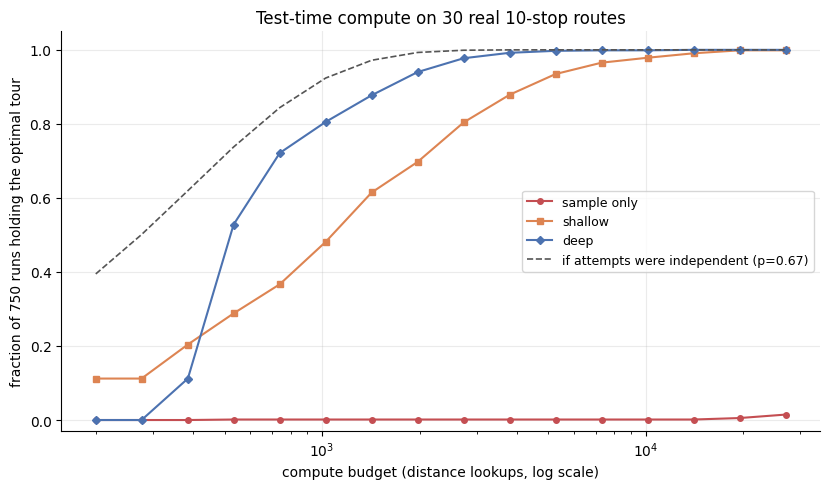

one deep attempt succeeds 66.7% of the time and costs 438 lookups on average

measured vs the independent-attempts prediction, at three budgets:
   1,423 lookups: measured 0.877   predicted 0.972
   2,737 lookups: measured 0.977   predicted 0.999
   7,299 lookups: measured 0.999   predicted 1.000

 sample only: first budget reaching 90% accuracy = never within 27000 lookups
     shallow: first budget reaching 90% accuracy = 5263 lookups
        deep: first budget reaching 90% accuracy = 1973 lookups


In [5]:
# WHAT: the budget curve, plus the prediction you would make if every attempt were an independent
#       coin flip with the measured single-attempt success rate.
# WHY : the gap between the dashed line and the solid one is the most useful thing on this chart,
#       and it is invisible in a table.
import matplotlib.pyplot as plt   # the notebook's inline backend renders this into the page

p_single = np.mean([np.isclose(att[0], opt, rtol=1e-9) for att, opt in zip(deep_attempts, run_optimum)])
lookups_per_attempt = BUDGET / np.mean([len(att) for att in deep_attempts])
independent = 1 - (1 - p_single) ** (grid / lookups_per_attempt)

fig, ax = plt.subplots(figsize=(8.4, 5.0))
styles = {"sample only": ("#C44E52", "o"), "shallow": ("#DD8452", "s"), "deep": ("#4C72B0", "D")}
for policy, (colour, marker) in styles.items():
    ax.plot(grid, results[policy][0], marker=marker, ms=4, color=colour, label=policy)
ax.plot(grid, independent, "--", color="#555555", lw=1.2,
        label=f"if attempts were independent (p={p_single:.2f})")
ax.set_xscale("log")
ax.set_xlabel("compute budget (distance lookups, log scale)")
ax.set_ylabel("fraction of 750 runs holding the optimal tour")
ax.set_ylim(-0.03, 1.05)
ax.set_title("Test-time compute on 30 real 10-stop routes")
ax.grid(alpha=0.25)
ax.legend(loc="center right", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"one deep attempt succeeds {p_single:.1%} of the time and costs "
      f"{lookups_per_attempt:.0f} lookups on average\n")
print("measured vs the independent-attempts prediction, at three budgets:")
for budget in (1423, 2737, 7299):
    j = int(np.where(grid == budget)[0][0])
    print(f"  {budget:>6,} lookups: measured {results['deep'][0][j]:.3f}   "
          f"predicted {independent[j]:.3f}")
print()
for policy in traces:
    reached = [g for g, a in zip(grid, results[policy][0]) if a >= 0.90]
    print(f"{policy:>12}: first budget reaching 90% accuracy = "
          f"{reached[0] if reached else 'never within ' + str(BUDGET)} lookups")

## 📊 What these numbers support — and what they do not

**More compute does buy accuracy, and the price rises steeply.** The deep policy goes from nothing to **94.0 %**
in its first 1,973 lookups, and then needs the remaining **25,027** lookups of the budget to collect the last
six points. That is the shape every test-time-compute plot in the literature has, and it is why "just sample
more" is a strategy with an expiry date.

**What the compute is spent *on* matters more than how much there is.** At the full 27,000-lookup budget the
three policies land at **1.5 %**, **99.9 %** and **100 %**. Scoring 2,700 random tours is worth less than a
single 2-opt attempt, which alone succeeds **66.7 %** of the time for **438** lookups. In excess kilometres the
same story is gentler but identical in direction: at a 740-lookup budget the deep policy's best tour is on
average **0.85 %** longer than optimal, while the full 27,000 lookups of random sampling end **8.9 %** above.

**But there is a crossover at the bottom, and it is the most instructive line in the table.** Below about 500
lookups the *shallow* policy is ahead — 20.4 % against 11.2 % at 385 lookups — for the plainest possible reason:
a deep attempt costs 438 lookups on average, so a budget of 200 buys **zero** complete attempts and therefore
zero accuracy. By 533 lookups deep is in front (52.8 % against 28.8 %) and it never gives the lead back. Reaching
90 % costs deep **1,973** lookups and shallow **5,263** — the deeper attempt is roughly **2.7 times as
compute-efficient** at that accuracy, and strictly worse at a budget too small to finish it. *How much thinking
per attempt* is a real decision with a real crossover, which is exactly what Snell et al. mean by
compute-optimal allocation.

**The textbook law is wrong here, and the gap is the lesson.** If every restart were an independent trial with
the measured success rate of 66.7 %, best-of-*n* accuracy would follow `1 − (1 − 0.667)ⁿ` — the dashed line. At
1,423 lookups that law predicts **97.2 %**; we measured **87.7 %**. At 2,737 lookups it predicts **99.9 %** and
we measured **97.7 %**. The restarts are not draws from one coin: they are draws from **thirty different coins**,
one per route, and averaging concave curves over a mixture of difficulties always lands below the curve of the
average. Part 5 splits the mixture open. This is the same arithmetic that makes agent pass^k numbers collapse
so much faster than a single pass@1 figure suggests.

**What these numbers do not support.** They do not show that a routing system needs 27,000 lookups: the excess
column says the practical answer arrives long before the provable one, and "exactly optimal" is our metric, not
a dispatcher's. They also say nothing about *sequential* budget use — every attempt here starts from scratch and
learns nothing from the last one, which is the crudest way to spend compute that exists.

## Part 5: The Same Curve, Split by Difficulty

The aggregate curve hides something. Some of our 30 real routes are solved by almost every attempt; others are
solved by almost none. Averaging them produces a curve that describes **no actual instance**.

Below we split the instances at the median of their single-attempt success rate and redraw. This is the
experimental fact behind Snell et al.'s central claim: the compute-optimal allocation depends on the difficulty
of the question, so a system that spends the same budget on every question is over-spending on most of them and
under-spending on the ones that matter.

In [6]:
# WHAT: group instances by how often ONE deep attempt already solves them, then redraw the budget
#       curve inside each group.
# WHY : "average accuracy at budget B" is a statement about a mixture. Splitting the mixture shows
#       that the same extra compute is nearly worthless on one half and decisive on the other.
first_attempt = np.array([np.isclose(att[0], opt, rtol=1e-9)
                          for att, opt in zip(deep_attempts, run_optimum)]).reshape(N_INSTANCES, N_SEEDS)
per_instance_p = first_attempt.mean(axis=1)
easy_mask = per_instance_p >= np.median(per_instance_p)

print("Single deep attempt succeeds on:")
print(f"  easiest instance {per_instance_p.max():.0%} of the time, "
      f"hardest instance {per_instance_p.min():.0%}, median {np.median(per_instance_p):.0%}")
print(f"  {easy_mask.sum()} instances at or above the median, {(~easy_mask).sum()} below\n")

run_is_easy = np.repeat(easy_mask, N_SEEDS)

def curve_subset(policy, mask):
    out = []
    for budget in grid:
        hits = []
        for (cum, best), opt, keep in zip(traces[policy], run_optimum, mask):
            if not keep:
                continue
            k = np.searchsorted(cum, budget, side="right")
            hits.append(np.isclose(best[k - 1] if k > 0 else np.inf, opt, rtol=1e-9))
        out.append(np.mean(hits))
    return np.array(out)

easy_curve, hard_curve = curve_subset("deep", run_is_easy), curve_subset("deep", ~run_is_easy)
for label, values in (("easy half", easy_curve), ("hard half", hard_curve)):
    print(f"{label}: " + "  ".join(f"{g:,}->{v:.0%}" for g, v in zip(grid[::4], values[::4])))

Single deep attempt succeeds on:
  easiest instance 100% of the time, hardest instance 20%, median 60%
  16 instances at or above the median, 14 below

easy half: 200->0%  740->91%  2,737->100%  10,123->100%
hard half: 200->0%  740->51%  2,737->95%  10,123->100%


## Part 6: When the Verifier Is Wrong

Best-of-*n* has a hidden requirement: **something has to pick the winner.** Cobbe et al. trained a model to do
it. We have been using the true tour length, which is a perfect verifier — and perfect verifiers are exactly
what you do not have in practice. A dispatcher does not know true drive time; they have an estimate.

So we keep every attempt exactly as it was and change only the **selection rule**: each candidate is measured
with 5 % multiplicative noise, and the run keeps whichever attempt *measured* shortest. The search is untouched.
Only the judgement is imperfect.

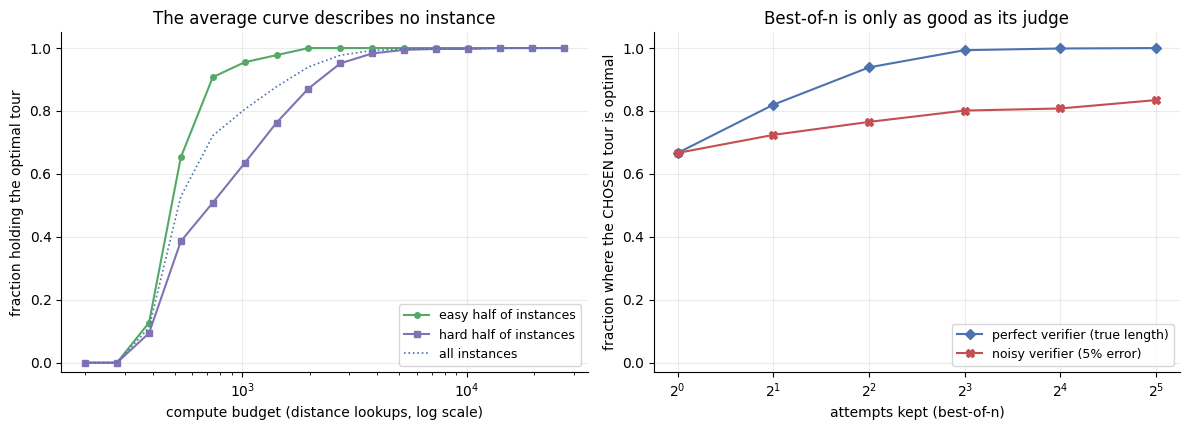

   n   perfect judge   noisy judge   accuracy lost
   1           0.667         0.667           0.0%
   2           0.820         0.724           9.6%
   4           0.939         0.765          17.3%
   8           0.993         0.801          19.2%
  16           0.999         0.808          19.1%
  32           1.000         0.835          16.5%


In [7]:
# WHAT: re-select the winner from the SAME deep attempts using a noisy measurement of tour length,
#       and plot true optimality against n for a perfect judge and a noisy one.
# WHY : this isolates selection from search. Nothing about the candidates changes; if the curves
#       differ, the difference is caused entirely by the quality of the thing choosing between them.
n_common = min(len(att) for att in deep_attempts)
attempt_matrix = np.array([att[:n_common] for att in deep_attempts])     # (750 runs, n_common attempts)
opt_col = run_optimum[:, None]

noise_rng = np.random.default_rng(7)
NOISE = 0.05                                          # 5% measurement error, as a multiplier
measured = attempt_matrix * noise_rng.normal(1.0, NOISE, attempt_matrix.shape)

n_values = [n for n in (1, 2, 4, 8, 16, 32, 64) if n <= n_common]
perfect, noisy = [], []
for n in n_values:
    perfect.append(np.isclose(attempt_matrix[:, :n].min(axis=1), run_optimum, rtol=1e-9).mean())
    picked = np.take_along_axis(attempt_matrix[:, :n],
                                measured[:, :n].argmin(axis=1)[:, None], axis=1)[:, 0]
    noisy.append(np.isclose(picked, run_optimum, rtol=1e-9).mean())

fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))

axes[0].plot(grid, easy_curve, marker="o", ms=4, color="#55A868", label="easy half of instances")
axes[0].plot(grid, hard_curve, marker="s", ms=4, color="#8172B3", label="hard half of instances")
axes[0].plot(grid, results["deep"][0], color="#4C72B0", lw=1.2, ls=":", label="all instances")
axes[0].set_xscale("log")
axes[0].set_xlabel("compute budget (distance lookups, log scale)")
axes[0].set_ylabel("fraction holding the optimal tour")
axes[0].set_title("The average curve describes no instance")

axes[1].plot(n_values, perfect, marker="D", ms=5, color="#4C72B0", label="perfect verifier (true length)")
axes[1].plot(n_values, noisy, marker="X", ms=6, color="#C44E52", label=f"noisy verifier ({NOISE:.0%} error)")
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("attempts kept (best-of-n)")
axes[1].set_ylabel("fraction where the CHOSEN tour is optimal")
axes[1].set_title("Best-of-n is only as good as its judge")

for ax in axes:
    ax.set_ylim(-0.03, 1.05)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"{'n':>4} {'perfect judge':>15} {'noisy judge':>13} {'accuracy lost':>15}")
for n, p, q in zip(n_values, perfect, noisy):
    print(f"{n:>4} {p:>15.3f} {q:>13.3f} {(p - q):>14.1%}")

## 📊 What Parts 5 and 6 show

**One budget cannot be right for thirty routes.** A single deep attempt solves the easiest of our real routes
**100 %** of the time and the hardest **20 %**; the median route sits at **60 %**. Split at that median and the
two halves need completely different budgets: at 740 lookups the easy half is already at **91 %** while the hard
half is at **51 %**; by 2,737 lookups the easy half is at **100 %** — every further lookup spent on it is wasted
— while the hard half is still at **95 %**, and only catches up (**100 %**) by 10,123 lookups, four times the
price. A system that spends the same amount on every request is simultaneously over-paying on most of them and
under-paying on the ones that decide the average. That is the practical content of "compute-optimal scaling
depends on question difficulty", and it is why 2026 systems try to *predict* difficulty before choosing a budget.

**Best-of-*n* is capped by its judge, not by its search.** The candidates in the right-hand panel are
byte-for-byte the same attempts in both curves; only the rule choosing the winner changed. With the true tour
length as judge, 32 attempts reach **100.0 %**. With a judge carrying **5 %** measurement error, the same 32
attempts reach **83.5 %** — and the curve is nearly flat after n = 8 (**80.1 % → 83.5 %** for four times the
compute). Read the two curves against each other and the arithmetic is uncomfortable: **32 attempts judged with
5 % error (83.5 %) are worth less than 4 attempts judged exactly (93.9 %)**, and barely more than **2** of them
(**82.0 %**). Sixteen times the compute bought less than fixing the judge would have.

That is a simulation of an effect that has been measured on real reward models: optimising hard against a proxy
eventually moves you away from the thing the proxy stands for (Gao, Schulman & Hilton, 2022). If you take one
engineering rule from this notebook, take this one — **before you buy more attempts, find out how good your
verifier is**, because that number is the ceiling on everything the extra attempts can do.

## 💬 Discuss

1. The budget curve flattens, but it never turns down: with a perfect judge, more attempts are never *worse*,
   only less useful per lookup. The noisy-judge curve in Part 6 flattens far below it. **Given a fixed budget,
   would you rather double your attempts or halve your verifier's error?** Argue it from the printed numbers,
   then say what you would need to measure in your own project to answer it there.
2. We defined accuracy as "found the provably optimal tour". The excess-length column tells a much gentler
   story — the best tour after a handful of attempts is already within a fraction of a percent of optimal. A
   dispatcher cares about kilometres, not about proofs. **Which metric would you put in front of the person
   paying for this system, and what does the other one protect you from?**
3. Part 5 shows the easy and hard halves need completely different budgets. Suppose you must decide the budget
   *before* seeing the route. What signal available at that moment might predict difficulty — and what is the
   risk of a system that decides for itself how long to think about your particular request?

## ✅ Summary

**What you built and measured** (every figure below was printed by the cells above):

- **30 real routing instances** drawn from the repository's **25,000-call sample** of the Montgomery County 911
  dispatch log — **85 recurring Norristown addresses** inside a **3.9 km × 2.9 km** area — and solved every one
  of them **exactly** by enumerating all 362,880 orderings (181,440 distinct tours) in **under a second**.
  Optimal tours ran from **3.33** to **9.12 km**
- The same enumeration at 15 stops would take **1.2 hours**, and at 20 stops **193 years** — which is why the
  rest of the notebook guesses
- **Three policies, one budget of 27,000 distance lookups, 750 runs each.** Final accuracy: random sampling
  **1.5 %**, shallow local search **99.9 %**, deep local search **100 %**. Reaching 90 % cost **1,973** lookups
  deep and **5,263** shallow — and below **500** lookups the shallow policy was the better buy
- The measured curve sits **below** the `1 − (1 − p)ⁿ` prediction (87.7 % against 97.2 % at 1,423 lookups)
  because our thirty routes are thirty different difficulties, not thirty draws from one coin
- Split at the median difficulty, the easy half saturates at **100 %** by 2,737 lookups while the hard half is
  still at **95 %** there
- A verifier with **5 %** error caps best-of-*n* at **83.5 %** where a perfect verifier reaches **100.0 %**

**The one sentence to keep:** compute buys accuracy only through a unit of work worth repeating and a judge that
can tell which repetition won — and both of those cap the curve long before the budget does.

**Where this goes next:** Unit 4 of this course turns "restart and keep the best" into the optimization
algorithms that do it deliberately, and Course 09 Unit 4 replaces the fixed budget with a rule (UCB) that decides how much to spend on each choice.

## ⚠️ Where this breaks

**A tour is not a proof, and neither is a paragraph.** Our verifier is exact and free: adding up ten distances
tells you the truth about a candidate. Almost nothing interesting has that property. Whether an essay is good,
whether a diagnosis is right, whether code is correct in the way the issue meant — these are the cases where
test-time compute is actually being sold, and in every one of them the judge is itself a model. Part 6 is the
mild version of that problem; the measured version is Gao, Schulman and Hilton's finding that optimising against
a proxy reward *"too much can hinder ground truth performance"*, for best-of-n as well as for RL.

**Ten stops is a toy, and its difficulty is not the difficulty that matters.** We chose 10 stops precisely
because enumeration still fits. Real dispatch problems have time windows, vehicle capacities, traffic and
priorities, and their local optima are structured very differently. Do not read our specific numbers as
statements about routing; read the *shape* of the curves.

**Our attempts are independent; a reasoning model's are not.** Every restart here throws away everything the
previous restart learned. That is the crudest possible use of a budget, which is why the field's interesting
work is about the alternatives — spending the budget sequentially (revise your own answer), or on a search
guided by a process reward model. Snell et al.'s "more than 4x" efficiency gain comes precisely from *not*
doing what we did.

**750 runs is enough to see a gap of ten points and not enough to see a gap of two.** With 750 runs a measured
accuracy near 90 % carries a standard error of about 1.1 percentage points — and that estimate is itself
optimistic, because 25 of every 750 runs share an instance and are therefore correlated. Two policies whose
curves cross inside a couple of points are, on this evidence, tied.

**These are the sample's numbers, and a bigger sample would move them.** This notebook reads the 25,000-call sample on purpose, so that every reader sees the same figures. Those 25,000 calls leave **85** recurring Norristown addresses in a 3.9 km × 2.9 km box; the full 663,522-call log leaves **865** of them across 4.8 km × 3.6 km. Thirty instances drawn from that larger, denser pool would shift every accuracy here by a few points — the curves would keep their shape and lose their third decimal. Download the full file (see `Course 04/datasets/DATA.md`), delete `prefer="sample"` from the first code cell, and you can measure exactly how much.

**Everything here is deterministic given the seeds, which is not a virtue.** Change `SEED` and every number in
this notebook moves a little. Change the township and they move more. A single seed is a single run, and this
notebook's own lesson — one attempt tells you very little — applies to the notebook.

## 📚 References

Best-of-*n*, the budget curve, and what breaks it:

1. Cobbe, K., Kosaraju, V., Bavarian, M., Chen, M., Jun, H., Kaiser, L., et al. (2021). *Training Verifiers to Solve Math Word Problems*. [arXiv:2110.14168](https://arxiv.org/abs/2110.14168) — the origin of the pattern this notebook implements: *"we generate many candidate solutions and select the one ranked highest by the verifier."*
2. Gao, L., Schulman, J., & Hilton, J. (2022). *Scaling Laws for Reward Model Overoptimization*. [arXiv:2210.10760](https://arxiv.org/abs/2210.10760) — what Part 6 simulates: optimising against an imperfect proxy, by best-of-n or by RL, until *"optimizing its value too much can hinder ground truth performance."*
3. Snell, C., Lee, J., Xu, K., & Kumar, A. (2024). *Scaling LLM Test-Time Compute Optimally can be More Effective than Scaling Model Parameters*. [arXiv:2408.03314](https://arxiv.org/abs/2408.03314) — compute-optimal allocation by question difficulty; *"more than 4x"* the efficiency of a best-of-N baseline, and outperforming a *"14x larger model"* on problems with non-trivial base success rates.
4. DeepSeek-AI (2025). *DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning*. [arXiv:2501.12948](https://arxiv.org/abs/2501.12948) — the openly documented reasoning model that made long inference-time thinking ordinary.
5. Muennighoff, N., Yang, Z., Shi, W., Li, X. L., Fei-Fei, L., Hajishirzi, H., et al. (2025). *s1: Simple test-time scaling*. [arXiv:2501.19393](https://arxiv.org/abs/2501.19393) — *budget forcing*: *"forcefully terminating the model's thinking process or lengthening it"*, with s1-32B *"exceeding o1-preview on competition math questions by up to 27%."*
6. Hart, P. E., Nilsson, N. J., & Raphael, B. (1968). *A Formal Basis for the Heuristic Determination of Minimum Cost Paths*. IEEE Transactions on Systems Science and Cybernetics, 4(2), 100–107. [doi:10.1109/TSSC.1968.300136](https://doi.org/10.1109/TSSC.1968.300136) — the A\* paper from lesson 02, and the other answer to "the complete search is too big": keep it complete, but guide it.